# Exploração pré-transformação RGB–térmica

Notebook independente para observar cada transformação antes do processamento e da contagem.

## Organização das entradas e saídas

As imagens source devem estar em `notebooks/input/`. Todos os resultados serão gravados diretamente em `notebooks/output/`.

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
NOTEBOOK_DIR = CURRENT_DIR if (CURRENT_DIR / 'input').is_dir() else CURRENT_DIR / 'notebooks'
INPUT_DIR = NOTEBOOK_DIR / 'input'
OUTPUT_DIR = NOTEBOOK_DIR / 'output'
RGB_PATH = INPUT_DIR / 'DJI_0789_W.JPG'
THERMAL_PATH = INPUT_DIR / 'DJI_0790_T.JPG'

assert RGB_PATH.exists(), f'Imagem RGB não encontrada: {RGB_PATH}'
assert THERMAL_PATH.exists(), f'Imagem térmica não encontrada: {THERMAL_PATH}'
img_rgb_raw = cv2.imread(str(RGB_PATH), cv2.IMREAD_COLOR)
img_th_raw = cv2.imread(str(THERMAL_PATH), cv2.IMREAD_COLOR)
assert img_rgb_raw is not None and img_th_raw is not None
print(f'RGB raw: {img_rgb_raw.shape[1]}x{img_rgb_raw.shape[0]} px')
print(f'Térmica raw: {img_th_raw.shape[1]}x{img_th_raw.shape[0]} px')

## 1. Imagens raw (antes de qualquer transformação)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, image, title in zip(axes, [img_rgb_raw, img_th_raw], ['RGB raw', 'Térmica raw']):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 2. Pré-processamento (somente recorte do pipeline)

As ações abaixo são separadas para permitir a inspeção individual. A imagem térmica é usada apenas como referência e não é alterada.

### 2.1 Ação: `fov_crop_ratio=0.70`

Primeiro aplicamos somente o recorte central. Neste teste a correção de lente está desligada, para isolar o efeito do `fov_crop_ratio`.

Antes: RGB raw 8000x6000 px
Depois: RGB cortada 5250x4200 px


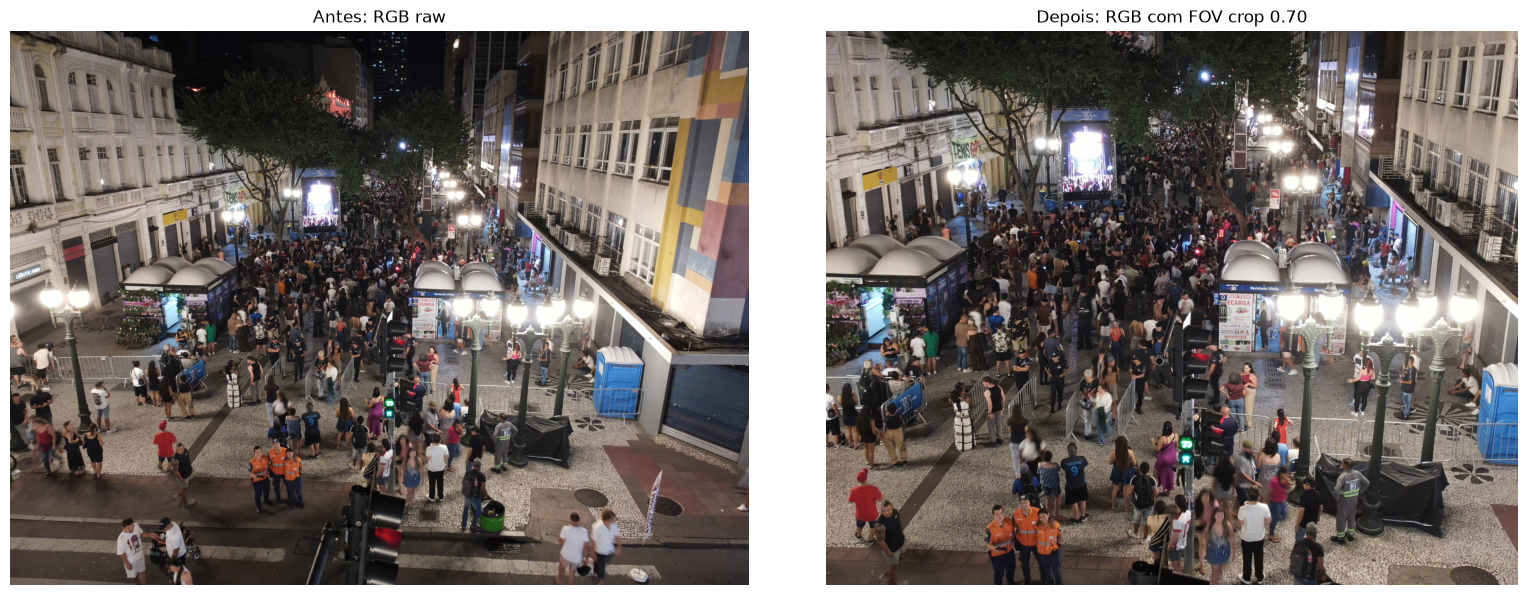

In [8]:
FOV_CROP_RATIO = 0.70

def crop_rgb_to_thermal_aspect(rgb_image, thermal_image, crop_ratio):
    rgb_height, rgb_width = rgb_image.shape[:2]
    thermal_height, thermal_width = thermal_image.shape[:2]
    target_aspect = thermal_width / thermal_height
    crop_height = int(rgb_height * crop_ratio)
    crop_width = int(crop_height * target_aspect)
    if crop_width > rgb_width:
        crop_width = rgb_width
        crop_height = int(crop_width / target_aspect)
    left = (rgb_width - crop_width) // 2
    top = (rgb_height - crop_height) // 2
    return rgb_image[top:top + crop_height, left:left + crop_width].copy()

img_rgb_after_fov_crop = crop_rgb_to_thermal_aspect(img_rgb_raw, img_th_raw, FOV_CROP_RATIO)
print(f'Antes: RGB raw {img_rgb_raw.shape[1]}x{img_rgb_raw.shape[0]} px')
print(f'Depois: RGB cortada {img_rgb_after_fov_crop.shape[1]}x{img_rgb_after_fov_crop.shape[0]} px')

# Antes/depois da ação de recorte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img_rgb_raw, cv2.COLOR_BGR2RGB))
axes[0].set_title('Antes: RGB raw')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_rgb_after_fov_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title('Depois: RGB com FOV crop 0.70')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 2.2 Ação: Overlay - Sobrepor par de imagens

In [ ]:
# Overlay específico desta etapa: RGB cortada versus térmica raw.
thermal_size_after_crop = (img_th_raw.shape[1], img_th_raw.shape[0])
img_rgb_fov_exact = cv2.resize(img_rgb_after_fov_crop, thermal_size_after_crop, interpolation=cv2.INTER_AREA)
overlay_fov_crop = cv2.addWeighted(img_rgb_fov_exact, 0.5, img_th_raw, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for axis, image, title in zip(axes, [img_rgb_fov_exact, img_th_raw, overlay_fov_crop], ['RGB após FOV crop', 'Térmica raw', 'Overlay do FOV crop (50/50)']):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

### 2.2 Ação: `undistort_lens=True`

Agora aplicamos somente a correção radial estimada da lente Wide sobre o resultado anterior. Assim é possível observar o efeito da lente sem misturá-lo com outra transformação.

In [ ]:
UNDISTORT_LENS = True

def undistort_wide_lens(rgb_image, enabled=True):
    if not enabled:
        return rgb_image.copy()
    height, width = rgb_image.shape[:2]
    camera_matrix = np.array(
        [[width * 0.8, 0, width / 2], [0, height * 0.8, height / 2], [0, 0, 1]],
        dtype=np.float32,
    )
    distortion = np.array([-0.04, 0.01, 0, 0], dtype=np.float32)
    return cv2.undistort(rgb_image, camera_matrix, distortion)

img_rgb_after_undistort = undistort_wide_lens(img_rgb_after_fov_crop, UNDISTORT_LENS)
print(f'Antes: RGB após crop {img_rgb_after_fov_crop.shape[1]}x{img_rgb_after_fov_crop.shape[0]} px')
print(f'Depois: RGB após undistort {img_rgb_after_undistort.shape[1]}x{img_rgb_after_undistort.shape[0]} px')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img_rgb_after_fov_crop, cv2.COLOR_BGR2RGB))
axes[0].set_title('Antes: RGB após FOV crop')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_rgb_after_undistort, cv2.COLOR_BGR2RGB))
axes[1].set_title('Depois: RGB com undistort')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Preparar canvas e comparar overlay

O resize abaixo não é uma transformação de alinhamento: ele apenas coloca a RGB processada no mesmo tamanho da térmica para que a comparação seja possível.

In [ ]:
thermal_size = (img_th_raw.shape[1], img_th_raw.shape[0])
img_rgb_final = cv2.resize(img_rgb_after_undistort, thermal_size, interpolation=cv2.INTER_AREA)
img_th_same_size = img_th_raw.copy()
blend_overlay = cv2.addWeighted(img_rgb_final, 0.5, img_th_same_size, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for axis, image, title in zip(axes, [img_rgb_final, img_th_same_size, blend_overlay], ['RGB crop + undistort', 'Térmica raw', 'Overlay 50/50']):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 4. Salvar resultados em `output/`

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rgb_output = OUTPUT_DIR / 'DJI_0789_W_rgb_crop_undistort.jpg'
thermal_output = OUTPUT_DIR / 'DJI_0790_T_thermal_raw.jpg'
overlay_output = OUTPUT_DIR / 'DJI_0789_W_thermal_overlay.jpg'
assert cv2.imwrite(str(rgb_output), img_rgb_final)
assert cv2.imwrite(str(thermal_output), img_th_same_size)
assert cv2.imwrite(str(overlay_output), blend_overlay)
print(f'RGB processada: {rgb_output}')
print(f'Térmica raw:     {thermal_output}')
print(f'Overlay:          {overlay_output}')